# MCP Policy Impact Analysis Workflow

This notebook integrates two AI agents:
1. **Rule Extraction Agent**: Extracts SBVR rules from new policy documents
2. **MCP GitHub Agent**: Fetches current rule configuration from GitHub and performs impact analysis

## Workflow:
```
New Policy Document → Extract Rules → Fetch GitHub Current Rules → Impact Analysis → Generate Report
```

## Prerequisites:
1. GitHub Personal Access Token (for MCP GitHub integration)
2. OpenAI API Key
3. A GitHub repository with current policy rules configuration

In [1]:
import os
import json
from typing import TypedDict, List, Annotated, Dict, Any
import operator

from langgraph.graph import StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# LangChain MCP Adapter for GitHub integration
from langchain_mcp_adapters.client import MultiServerMCPClient

## 1. Define Enhanced State

Compared to the original agent, we need to track more information throughout the workflow:

In [2]:
class PolicyImpactAnalysisState(TypedDict):
    """Extended state for policy impact analysis workflow"""
    # Conversation history
    messages: Annotated[List[BaseMessage], operator.add]
    
    # Newly extracted rules from policy documents
    new_rules: List[Dict[str, Any]]
    
    # Current rules from GitHub repository
    current_rules: List[Dict[str, Any]]
    
    # Impact analysis report
    impact_report: Dict[str, Any]
    
    # Workflow control flag
    next_step: str  # "extract" | "fetch_github" | "analyze" | "done"

## 2. Build the Toolbox

### Tool 1 & 2: Original SBVR Extraction and General QA Tools

In [3]:
# Import from the same directory (Agent 1)
from generic_engine_builder import build_search_engine

# Configure paths - adjusted for Agent 1 folder
INDEX_ROOT = os.path.join("..", "kyc_workflow", "output")
QA_PROMPT_PATH = "cust_local_search_system_prompt.txt"
SBVR_PROMPT_PATH = "sbvr_local_search_system_prompt.txt"
IMPACT_ANALYSIS_PROMPT_PATH = "impact_analysis_system_prompt.txt"

# Build SBVR extraction engine
print("🔧 Building SBVR Extraction engine...")
sbvr_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=SBVR_PROMPT_PATH,
    response_type="Return SBVR-style business rules in strict JSON format."
)

# Build general QA engine
print("🔧 Building General QA engine...")
qa_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=QA_PROMPT_PATH,
    response_type="multiple paragraphs"
)

print("🔧 Building Impact detect engine...")
impact_engine = build_search_engine(
    index_root=INDEX_ROOT,
    system_prompt_path=IMPACT_ANALYSIS_PROMPT_PATH,
    response_type="Return validation result in strict JSON format."
)
print("✅ Search engines ready!")

🔧 Building SBVR Extraction engine...
🔧 Building General QA engine...
🔧 Building Impact detect engine...
✅ Search engines ready!


In [4]:
@tool
async def sbvr_extraction(question: str) -> str:
    """
    Extract SBVR-formatted rules from policy documents.
    Use this when user asks to "extract rules", "find obligations", "list requirements", etc.
    
    Args:
        question: Question about rule extraction
    
    Returns:
        JSON string containing list of rules
    """
    print("🔍 Executing SBVR rule extraction...")
    try:
        result = await sbvr_engine.search(question)
        return result.response  # Return JSON string
    except Exception as e:
        return json.dumps({"error": str(e), "rules": []})

@tool
async def general_qa(question: str) -> str:
    """
    Answer general questions about policies.
    Suitable for definitions, summaries, background information, etc.
    """
    print("💬 Executing general Q&A...")
    try:
        result = await qa_engine.search(question)
        return result.response
    except Exception as e:
        return f"Error: {e}"

### Tool 3: GitHub MCP Integration (LangChain Adapter - HTTP Transport)

**Using LangChain MCP Adapter with HTTP Transport** to connect to GitHub's cloud MCP service.

In [5]:
# Initialize MCP Client for GitHub using LangChain Adapter
print("🔧 Initializing MCP GitHub Client with LangChain Adapter...")

async def initialize_mcp_github_client():
    """Initialize MCP client using LangChain adapter and return GitHub tools"""
    github_token = os.environ.get("GITHUB_PERSONAL_ACCESS_TOKEN", "")
    
    if not github_token:
        print("⚠️ Warning: GITHUB_PERSONAL_ACCESS_TOKEN not set")
        return None, []
    
    try:
        # Configure MCP client with GitHub server (HTTP Transport)
        print("🔌 Connecting to GitHub MCP Cloud Service (HTTP)...")
        client = MultiServerMCPClient({
            "github": {
                "transport": "http",
                "url": "https://api.githubcopilot.com/mcp/",
                "headers": {
                    "Authorization": f"Bearer {github_token}"
                }
            }
        })
        
        # Get all available GitHub tools (auto-discovery)
        tools = await client.get_tools()
        print(f"✅ MCP GitHub Client initialized with {len(tools)} tools available")
        
        # List available tools
        print("📋 Available GitHub tools:")
        for tool in tools:
            print(f"   - {tool.name}")
        
        return client, tools
    except Exception as e:
        print(f"❌ Failed to initialize MCP client: {e}")
        return None, []

# Initialize and get GitHub tools
mcp_client_result = await initialize_mcp_github_client()
print(mcp_client_result)
if mcp_client_result:
    mcp_github_client, github_mcp_tools = mcp_client_result
    # Find the get_file_contents tool
    github_read_file_tool = next(
        (t for t in github_mcp_tools if t.name == "get_file_contents"), 
        None
    )
    if github_read_file_tool:
        print(f"✅ Found GitHub file reading tool: {github_read_file_tool.name}")
    else:
        print("⚠️ get_file_contents tool not found in available tools")
else:
    mcp_github_client = None
    github_mcp_tools = []
    github_read_file_tool = None
    print("⚠️ GitHub MCP tools not available")

# Create a wrapper tool for our specific use case
@tool
async def fetch_current_policy_rules(owner: str, repo: str, file_path: str, branch: str = "main") -> str:
    """
    Fetch current policy rules configuration from GitHub repository using MCP Adapter.
    
    Args:
        owner: GitHub repository owner (username or organization)
        repo: Repository name
        file_path: Path to the rule configuration file (default: policy_rules.json)
        branch: Branch name (default: main)
    
    Returns:
        Current rules as JSON string
    
    Example:
        owner="myorg", repo="compliance-rules", file_path="config/policy_rules.json"
    """
    print(f"📥 Fetching current rules from GitHub: {owner}/{repo}/{file_path}")
    
    try:
        if not github_read_file_tool:
            raise Exception("GitHub MCP tools not initialized. Please check GITHUB_PERSONAL_ACCESS_TOKEN and MCP setup.")
        
        # Use the MCP tool to read file (LangChain tool interface)
        result = await github_read_file_tool.ainvoke({
            "owner": owner,
            "repo": repo,
            "path": file_path,
            "branch": branch
        })

        print(result)
        print(len(result))
        print(type(result))
        
        # Extract content from result
        content = None
        
        # Handle list of dictionaries (MCP format)
        if isinstance(result, list):
            # Find the text content (usually in the second element)
            for item in result:
                if isinstance(item, dict) and item.get('type') == 'text':
                    text = item.get('text', '')
                    # Skip metadata messages like "successfully downloaded..."
                    if not text.startswith('successfully downloaded'):
                        content = text
                        break
        else:
            content = str(result)
        
        if not content:
            raise Exception("Could not extract file content from MCP response")
        
        print(f"✅ Successfully fetched and extracted {len(content)} characters from GitHub")
        return content
                    
    except Exception as e:
        error_msg = f"Failed to fetch from GitHub: {str(e)}"
        print(f"❌ {error_msg}")
        
        # Return error in JSON format
        return json.dumps({
            "error": error_msg,
            "rules": [],
            "note": "Make sure GITHUB_PERSONAL_ACCESS_TOKEN is set and you have access to the repository"
        })

print("✅ GitHub MCP tool defined (using LangChain Adapter)")

🔧 Initializing MCP GitHub Client with LangChain Adapter...
🔌 Connecting to GitHub MCP Cloud Service (HTTP)...
✅ MCP GitHub Client initialized with 40 tools available
📋 Available GitHub tools:
   - add_comment_to_pending_review
   - add_issue_comment
   - assign_copilot_to_issue
   - create_branch
   - create_or_update_file
   - create_pull_request
   - create_repository
   - delete_file
   - fork_repository
   - get_commit
   - get_file_contents
   - get_label
   - get_latest_release
   - get_me
   - get_release_by_tag
   - get_tag
   - get_team_members
   - get_teams
   - issue_read
   - issue_write
   - list_branches
   - list_commits
   - list_issue_types
   - list_issues
   - list_pull_requests
   - list_releases
   - list_tags
   - merge_pull_request
   - pull_request_read
   - pull_request_review_write
   - push_files
   - request_copilot_review
   - search_code
   - search_issues
   - search_pull_requests
   - search_repositories
   - search_users
   - sub_issue_write
   - updat

### Tool 4: Impact Analysis (Core Functionality)

In [6]:
@tool
async def analyze_policy_impact(current_rules_json: str) -> str:
    """
    Analyze policy impact by validating each rule individually against latest documents.
    Uses the global impact_engine for per-rule validation.
    
    Args:
        current_rules_json: Current rules from GitHub as JSON string
    
    Returns:
        Comprehensive impact analysis report in structured format
    """
    print("📊 Executing per-rule impact analysis...")
    
    try:
        # 1. Parse current rules
        current_data = json.loads(current_rules_json)
        current_rules = current_data if isinstance(current_data, list) else current_data.get("rules", [])
        
        if not current_rules:
            return "Error: No current rules provided or JSON is empty."
        
        rule_count = len(current_rules)
        print(f"📥 Loaded {rule_count} current rules from GitHub")
        
        # 2. Load the per-rule validation prompt template
        PER_RULE_PROMPT_PATH = "per_rule_validation_prompt.txt"
        with open(PER_RULE_PROMPT_PATH, "r", encoding="utf-8") as f:
            per_rule_prompt_template = f.read()
        
        # 3. Process each rule individually using global impact_engine
        validation_results = []
        
        for idx, rule in enumerate(current_rules, 1):
            rule_id = rule.get("id", f"UNKNOWN-{idx}")
            print(f"\n🔍 [{idx}/{rule_count}] Validating rule: {rule_id}")
            
            # Format the query for this specific rule
            rule_query = per_rule_prompt_template.format(
                rule_json=json.dumps(rule, ensure_ascii=False, indent=2)
            )
            
            # Execute validation query using global impact_engine
            try:
                result = await impact_engine.search(rule_query)
                validation_results.append({
                    "rule_id": rule_id,
                    "validation": result.response,
                    "success": True
                })
                print(f"✅ Rule {rule_id} validated")
            except Exception as e:
                print(f"❌ Error validating {rule_id}: {e}")
                validation_results.append({
                    "rule_id": rule_id,
                    "validation": f"Error: {str(e)}",
                    "success": False
                })
        
        # 4. Generate consolidated report
        print("\n📋 Generating consolidated impact analysis report...")
        
        report_sections = []
        for result in validation_results:
            if result["success"]:
                report_sections.append(f"## Rule: {result['rule_id']}\n\n{result['validation']}\n")
            else:
                report_sections.append(f"## Rule: {result['rule_id']}\n\n**Error**: {result['validation']}\n")
        
        final_report = "\n".join(report_sections)
        
        print(f"✅ Impact analysis complete for {rule_count} rules")
        return final_report
            
    except json.JSONDecodeError as e:
        return f"Error: Failed to parse JSON input. Details: {str(e)}"
    except Exception as e:
        return f"Error: Impact analysis failed. Details: {str(e)}"

print("✅ Enhanced per-rule analyze_policy_impact tool defined")

✅ Enhanced per-rule analyze_policy_impact tool defined


## 3. Define LangGraph Nodes

### Agent Node: LLM Decision Center

In [7]:
# Collect all tools
tools = [sbvr_extraction, general_qa, fetch_current_policy_rules, analyze_policy_impact]

# Initialize LLM with tool binding
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools)

def agent_node(state: PolicyImpactAnalysisState) -> PolicyImpactAnalysisState:
    """
    Agent node: LLM decides the next action based on current state
    """
    print("\n🤖 Agent is thinking...")
    
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    
    # LangGraph automatically adds new messages to the messages list
    return {"messages": [response]}

### Tool Node: Execute Tool Calls

In [8]:
# LangGraph's pre-built tool node
tool_node = ToolNode(tools)

### Routing Function: Decide Execution Flow

In [9]:
def should_continue(state: PolicyImpactAnalysisState) -> str:
    """
    Decide whether to continue executing tools or end the workflow
    """
    messages = state["messages"]
    last_message = messages[-1]
    
    # If LLM called tools, continue to tools node
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print(f"➡️ Routing to tool execution: {len(last_message.tool_calls)} tool call(s)")
        return "tools"
    
    # Otherwise, end
    print("✅ Workflow completed")
    return END

## 4. Build LangGraph Workflow

In [10]:
# Create state graph
workflow = StateGraph(PolicyImpactAnalysisState)

# Add nodes
workflow.add_node("agent", agent_node)
workflow.add_node("tools", tool_node)

# Define edges (execution flow)
workflow.add_edge(START, "agent")  # Start → agent
workflow.add_conditional_edges(
    "agent",
    should_continue,  # agent → decide based on should_continue
    {"continue": "tools", "end": END}
)
workflow.add_edge("tools", "agent")  # tools → agent (creates a loop)

# Compile into executable graph
app = workflow.compile()

print("✅ LangGraph workflow built successfully!")

✅ LangGraph workflow built successfully!


## 5. Visualize Workflow (Optional)

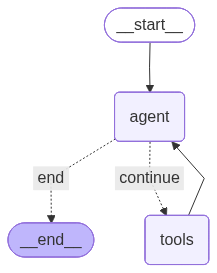

In [11]:
# Visualize graph structure if you have graphviz installed
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Cannot generate graph (graphviz required): {e}")

## 6. Execute Complete Impact Analysis Workflow

### Scenario: New policy document published, need to analyze impact

**Important**: Update the parameters below with your actual GitHub repository information

In [ ]:
# async def run_impact_analysis(github_owner: str, github_repo: str, config_file: str = "policy_rules.json"):
#     """
#     Executes the complete, autonomous impact analysis workflow.
    
#     This function sets up the initial state for the LangGraph agent, providing it with a
#     system prompt (its instructions) and a user query (the task). The agent will then
#     autonomously decide which tools to call in sequence to fulfill the request.
    
#     Args:
#         github_owner: GitHub repository owner (username or organization).
#         github_repo: Repository name.
#         config_file: Path to the rule configuration file in the repo.
#     """
    
#     # 1. Define the user's high-level goal.
#     user_query = f"""
# Please perform a full impact analysis. 
# First, get the current rules from the GitHub repository '{github_owner}/{github_repo}' from the file '{config_file}'. 
# Then, analyze these rules against the latest policy documents and generate a structured report.
# Please execute all steps automatically.
# """
    
#     # 2. Create the initial state for the agent. This includes the "System Prompt" which acts as its core instructions.
#     initial_state = {
#         "messages": [
#             SystemMessage(content=f"""
# You are an expert financial compliance policy impact analysis assistant. Your goal is to autonomously perform a full impact analysis by using your tools.

# **Your Instructions:**
# When the user asks for an impact analysis, you MUST follow these steps in order:
# 1.  Call the `fetch_current_policy_rules` tool to get the rules from GitHub. Use these exact parameters: owner="{github_owner}", repo="{github_repo}", file_path="{config_file}".
# 2.  Once you have the rules from the previous step, call the `analyze_policy_impact` tool, passing the result into the `current_rules_json` parameter.
# 3.  After the analysis is complete, present the final report to the user.

# Do not ask for confirmation. Execute the plan proactively.
# """),
#             HumanMessage(content=user_query)
#         ],
#         # Initialize other state variables as empty
#         "new_rules": [],
#         "current_rules": [],
#         "impact_report": {},
#         "next_step": "fetch_github"
#     }
    
#     # 3. Execute the workflow by invoking the compiled LangGraph app.
#     print("🚀 Starting autonomous impact analysis workflow...\n")
#     print("="*80)
    
#     final_state = await app.ainvoke(initial_state)
    
#     print("\n" + "="*80)
#     print("\n📋 Final Agent Report:\n")
    
#     # 4. Print the final, user-facing message from the agent.
#     for msg in final_state["messages"]:
#         if isinstance(msg, AIMessage) and not msg.tool_calls:
#             print(msg.content)
    
#     return final_state

# # --- Execute the Agent ---
# # This will start the entire automated process.
# # Make sure your GITHUB_PERSONAL_ACCESS_TOKEN and OPENAI_API_KEY are set.
# result = await run_impact_analysis(
#     github_owner="JJchan123", 
#     github_repo="compliance_rule_configuration", 
#     config_file="policy_rules.json"
# )

## 7. Individual Tool Testing (For Debugging)

### Test Rule Extraction

In [ ]:
# # Test SBVR extraction
# test_result = await sbvr_extraction.ainvoke({
#     "question": "Extract all obligations related to non-account holder"
# })

# print("Extracted Rules:")
# print(json.dumps(json.loads(test_result), ensure_ascii=False, indent=2))

### Test GitHub Rules Fetch (Real MCP Integration)

In [ ]:
# Test GitHub MCP - UPDATE WITH YOUR REPO INFO
# Make sure GITHUB_PERSONAL_ACCESS_TOKEN is set in environment variables
current_rules = await fetch_current_policy_rules.ainvoke({
    "owner": "JJchan123",  # e.g., "myusername"
    "repo": "compliance_rule_configuration",          # e.g., "compliance-rules"
    "file_path": "policy_rules.json"  # path to your config file
})

print("Current Rules from GitHub:")
print(type(current_rules))
print(current_rules)

### Test Impact Analysis

In [ ]:
impact_report = await analyze_policy_impact.ainvoke({
    "current_rules_json": current_rules  # Only need current rules from GitHub
})

print("=" * 80)
print("📋 Enhanced Impact Analysis Report")
print("=" * 80)
print(impact_report)